# Random Forest Model for AI Tweet Detection

This notebook trains a Random Forest model to classify tweets as human-written or AI-generated.

It uses the same dataset and the same 80/20 train-test split setup as the BERT notebook so the results can be compared fairly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 140)


## Load dataset

In [2]:
DATA_URL = "https://raw.githubusercontent.com/wagueacarinetech-hue/Machine-Learning-project-22D/main/combined_ai_tweet_detection_dataset.csv"

local_paths = [
    Path("combined_ai_tweet_detection_dataset.csv"),
    Path("data/combined_ai_tweet_detection_dataset.csv")
]

df = None

for path in local_paths:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded dataset from local file: {path}")
        break

if df is None:
    df = pd.read_csv(DATA_URL)
    print("Loaded dataset from GitHub URL")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())
display(df["label"].value_counts().sort_index().to_frame("count"))


Loaded dataset from local file: combined_ai_tweet_detection_dataset.csv
Dataset shape: (35443, 6)
Columns: ['text', 'label', 'source_dataset', 'original_label', 'generator_type', 'split']


,text,label,source_dataset,original_label,generator_type,split
0,YEA now that note GOOD,1,TweepFake,bot,others,train
1,Listen to This Charming Man by The Smiths https://t.co/r12OIXkfUO,0,TweepFake,human,human,train
2,wish i can i would be seeing other hoes on the worst part,1,TweepFake,bot,others,train
3,The decade in the significantly easier schedule I Don't like h…,1,TweepFake,bot,others,train
4,"""Theim class=\""alignnone size-full wp-image-6017 \"" src=\""https://t.co/LiAsQsbs99\"" alt=\""\"" /&gt;\r\n&lt;p id=\""dyD\""&gt;&lt;img class=...",1,TweepFake,bot,rnn,train


,count
label,
0,15647
1,19796


The dataset uses `0` for human-written tweets and `1` for AI-generated or machine-generated tweets.


## Prepare data

In [3]:
df = df.dropna(subset=["text", "label"]).copy()

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", len(X_train), "tweets")
print("Testing set:", len(X_test), "tweets")
print("\nTraining labels:")
display(y_train.value_counts().sort_index().to_frame("count"))
print("\nTesting labels:")
display(y_test.value_counts().sort_index().to_frame("count"))


Training set: 28354 tweets
Testing set: 7089 tweets

Training labels:


,count
label,
0,12517
1,15837



Testing labels:


,count
label,
0,3130
1,3959


The split is stratified, so the train and test sets keep a similar human-vs-AI label balance.


## Train Random Forest model

In [4]:
rf_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=10000,
        min_df=2,
        max_df=0.95
    )),
    ("random_forest", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest model trained.")


Random Forest model trained.


TF-IDF turns the tweet text into numerical features. Random Forest then uses those features to predict whether each tweet is human-written or AI-generated.


## Evaluate model

In [5]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1]
})

display(rf_results)

print("Detailed classification report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI Generated"]))


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.82367,0.807911,0.897701,0.850443


Detailed classification report:
              precision    recall  f1-score   support

       Human       0.85      0.73      0.79      3130
AI Generated       0.81      0.90      0.85      3959

    accuracy                           0.82      7089
   macro avg       0.83      0.81      0.82      7089
weighted avg       0.83      0.82      0.82      7089



Accuracy shows the overall percent of correct predictions. Precision shows how often tweets predicted as AI-generated were actually AI-generated. Recall shows how many actual AI-generated tweets the model caught. F1-score balances precision and recall.


## Confusion matrix

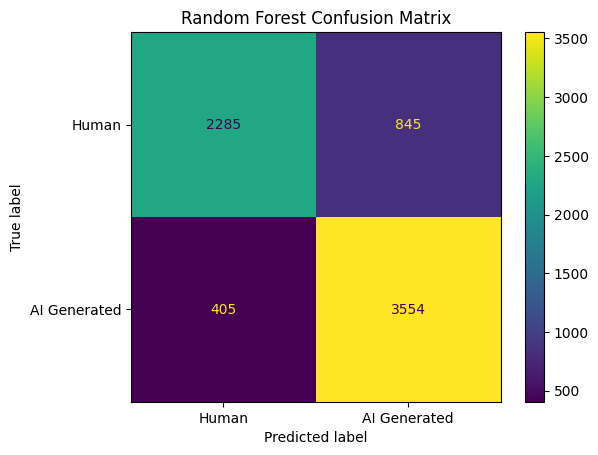

,Predicted Human,Predicted AI Generated
Actual Human,2285,845
Actual AI Generated,405,3554


In [6]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI Generated"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

cm_df = pd.DataFrame(
    cm,
    index=["Actual Human", "Actual AI Generated"],
    columns=["Predicted Human", "Predicted AI Generated"]
)

display(cm_df)


The confusion matrix shows where the model is correct and where it makes mistakes. The most important errors are false positives and false negatives because they show when the model confuses human tweets with AI tweets.


## Performance by dataset source

In [7]:
test_results = df.loc[X_test.index].copy()
test_results["prediction"] = y_pred
test_results["ai_probability"] = y_prob

source_rows = []

for source_name, source_group in test_results.groupby("source_dataset"):
    source_rows.append({
        "source_dataset": source_name,
        "rows": len(source_group),
        "accuracy": accuracy_score(source_group["label"], source_group["prediction"]),
        "precision": precision_score(source_group["label"], source_group["prediction"], zero_division=0),
        "recall": recall_score(source_group["label"], source_group["prediction"], zero_division=0),
        "f1_score": f1_score(source_group["label"], source_group["prediction"], zero_division=0)
    })

source_performance = pd.DataFrame(source_rows)
display(source_performance)


,source_dataset,rows,accuracy,precision,recall,f1_score
0,ElectAI,1979,0.981304,0.983087,0.990767,0.986912
1,TweepFake,5110,0.762622,0.724497,0.846335,0.780691


This table checks whether the model performs similarly on TweepFake and ElectAI. This matters because a model can look strong overall but still perform worse on one dataset source.


## Important words/features

In [8]:
vectorizer = rf_model.named_steps["tfidf"]
forest = rf_model.named_steps["random_forest"]

feature_names = vectorizer.get_feature_names_out()
importances = forest.feature_importances_

top_features = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(25)
)

display(top_features)


,feature,importance
4370,https,0.141840
2084,county,0.016784
9285,vote,0.011820
9387,voter fraud,0.011052
3592,fraud,0.010307
9486,voting,0.009193
6627,people,0.008534
9385,voter,0.006181
5582,machines,0.006014
9445,votes,0.005630


These features show which words or phrases helped the Random Forest model most. They should not be treated as perfect explanations, but they give a useful view of what the model is paying attention to.


## Example mistakes

In [9]:
false_positives = test_results[
    (test_results["label"] == 0) & (test_results["prediction"] == 1)
][["text", "source_dataset", "original_label", "generator_type", "ai_probability"]].head(10)

false_negatives = test_results[
    (test_results["label"] == 1) & (test_results["prediction"] == 0)
][["text", "source_dataset", "original_label", "generator_type", "ai_probability"]].head(10)

print("False positives: human tweets predicted as AI-generated")
display(false_positives)

print("False negatives: AI-generated tweets predicted as human")
display(false_negatives)


False positives: human tweets predicted as AI-generated


,text,source_dataset,original_label,generator_type,ai_probability
17347,masturbating is definitely <U+0001F4AF>,TweepFake,human,human,0.562586
22607,We're Designing A Special Capsule Collection For The Rome Pop Up. |||,TweepFake,human,human,0.943398
18936,@JayPat21 I didn’t eat the pani puri but had the aloo tikki instead :/,TweepFake,human,human,0.860000
17201,remember the time esa and i snuck into an amp conference for free food,TweepFake,human,human,0.598460
685,"if you dont like earth, wind, and fire, there is something wrong with you",TweepFake,human,human,0.585904
8293,"""we build tools to enable self-service. It’s okay for people to be dependent on our tools, but it’s important that they don’t become dep...",TweepFake,human,human,0.560000
22875,@ChoudhuryAdam yes and i need to start posting more <U+0001F62D>,TweepFake,human,human,0.561484
25522,"I Am Merely Here For The Youth, And We Will Take Out Rightful Place As The Leaders Of #TheNextGeneration. Are You Ready?",TweepFake,human,human,0.899026
4676,i’ve always wanted to try one of those gas station boner pills <U+0001F633><U+0001F633> who wants to record me and my experience when i ...,TweepFake,human,human,0.740000
15342,@BleacherReport 50-2 if we count The Cat in the Hat,TweepFake,human,human,0.524691


False negatives: AI-generated tweets predicted as human


,text,source_dataset,original_label,generator_type,ai_probability
10649,any hijabi gamer girl keep saying i’m gonna eat a full time for this is joe energy <U+0001F62D>,TweepFake,bot,others,0.490000
25047,#ModiOpekurma on the Contribution https://t.co/QVZ45J31UH the people of Gold is the Yoga Day.,TweepFake,bot,rnn,0.350000
20664,"please deep like us on IG, i have a bunch of nanites i want <U+0001F499><U+0001F433>",TweepFake,bot,gpt2,0.274369
17950,"I'm not going to get into the philosophical issues around proprietary/sharing registry issues, as that's a different debate than the ""wh...",TweepFake,bot,gpt2,0.349203
1239,oh my god. my wife tried to help me out of my box. oh god oh god oh please no baby. no one please no oh no ahhh please no. no no it hurt...,TweepFake,bot,gpt2,0.264544
4098,Borat is biased because I am Mr,TweepFake,bot,others,0.495818
23943,this a dick,TweepFake,bot,others,0.120000
4946,YEAH I’m 70,TweepFake,bot,others,0.384541
11727,praying for him,TweepFake,bot,others,0.490824
2054,Never Mind It's been a,TweepFake,bot,others,0.299639


False positives show human tweets that the model wrongly flagged as AI-generated. False negatives show AI-generated tweets that the model missed. Looking at these examples helps explain the model beyond just the accuracy score.


## Final takeaway

The Random Forest model is a useful baseline for comparing against BERT. If BERT performs better, it most likely means BERT is better at understanding context and sentence structure. If Random Forest performs close to BERT, then the simpler model is still strong enough to be useful for this task.
